# Polygonal Array System

**Polygonal Array System (다각형 배열 시스템)** is a general-purpose system for constructing and indexing arrays on regular polygons.  
정$n$각형을 기반으로 **보드게임판(Board Game Boards), 다각진(Magic Polygons), 기타 다각형 격자(Polygonal Grids)**를 일관된 방식으로 생성하고 표현하기 위한 범용 배열 시스템입니다.

The system separates **geometric structure, logical array indexing, and assigned data**.  
즉 실제 도형의 좌표와 연결 관계인 **geometry**, 각 위치를 행렬 형태로 다루기 위한 **logical array**, 그리고 숫자·기물·상태 등의 **data**를 서로 분리하여 같은 다각형 구조를 여러 목적으로 재사용할 수 있도록 합니다.

## Main Applications / 주요 활용 분야

### 1. Board Game Boards / 보드게임판

Regular-polygon-based boards can be constructed as an indexed array while preserving their geometric structure.  
정다각형을 기반으로 하는 게임판의 **칸 또는 교차점, 연결선, 이동 경로, 특수 구역** 등을 논리적 배열과 실제 좌표에 동시에 대응시킬 수 있습니다.

게임 규칙은 logical array를 기준으로 처리하면서, 실제 화면 출력은 corresponding geometric coordinates를 이용할 수 있으므로 **game logic과 board visualization을 분리**하기에 적합합니다.

### 2. Magic Polygons / 다각진

The same array system can represent **magic polygons and other polygonal magic figures** by assigning numbers to indexed positions.  
각 sector를 일정한 matrix structure로 저장하고 중앙점 및 필요한 방사·대각 방향을 별도로 정의함으로써, 오각진을 비롯한 다양한 **다각진의 수 배열과 magic-sum constraints**를 표현할 수 있습니다.

A solution can therefore be stored as an array and visualized on the corresponding polygon without rewriting the geometry for each individual magic figure.  
즉 해(solution)와 도형(geometry)을 분리하여 동일한 다각형 구조에서 여러 해를 손쉽게 다시 출력할 수 있습니다.

### 3. Other Polygonal Grids / 기타 다각형 격자

The system can also be used for general polygonal grids that are not necessarily board games or magic figures.  
숫자, 문자, 기호, 상태값 등을 정다각형 위에 배열하는 **combinatorial grids, node networks, mathematical figures, custom polygonal diagrams** 등의 표현에도 사용할 수 있습니다.

## Design Principle / 설계 원칙

The basic design is:

**Geometry → Logical Labels → Data → Visualization**

- **Geometry / 기하 구조**: 실제 점의 좌표와 격자선 생성
- **Logical Labels / 논리 레이블**: 각 점을 sector와 matrix index에 대응
- **Data / 데이터**: 숫자, 게임 기물, 상태 등의 값 배정
- **Visualization / 시각화**: 동일한 geometry 위에 목적에 맞는 내용을 출력

이러한 분리를 통해 하나의 **Polygonal Array System**을 보드게임판, 다각진 및 기타 다각형 격자의 공통 기반으로 사용할 수 있습니다.

## License / 라이선스

### Source Code

The source code in this repository is licensed under the **MIT License**.

본 저장소의 소스 코드는 **MIT License**에 따라 배포됩니다.



### Original Magic Polygon Solutions

The original Magic Polygon solutions discovered by the author and included
in this repository are dedicated to the public domain under
**CC0 1.0 Universal**.

Attribution is not legally required. However, when these solutions are
reproduced or cited in academic, educational, or mathematical contexts,
attribution to the original discoverer is appreciated. Either of the
following forms may be used:

> Donghwi Park, Ph.D. (2026)

or

> 박동휘 박사 (2026년)

작성자가 직접 탐색하여 발견하고 본 저장소에 수록한 Magic Polygon의
수 배열은 **CC0 1.0 Universal**을 통해 퍼블릭 도메인에 준하여 공개합니다.

저자 표시는 법적인 이용 조건이 아닙니다. 다만 학술·교육·수학적 목적으로
해당 해를 인용하거나 재수록하는 경우 최초 발견자에 대한 출처 표시를
권장합니다. 다음의 영문 또는 한글 표기를 사용할 수 있습니다.

> Donghwi Park, Ph.D. (2026)

또는

> 박동휘 박사 (2026년)

## Example and Sources / 예제 및 출처

The specific numerical arrangement used for the **31-node Magic Pentagon (Magic Sum 80)** is an **original solution discovered by the author through computational search**.

본 프로젝트에 수록된 **31-node Magic Pentagon(마법합 80)**의 구체적인 수 배열은 작성자가 직접 탐색하여 발견한 **original solution (자체 발견 해)**입니다.


The **19-node Magic Triangle** included in this project is reproduced from a solution presented by its original author on Wikimedia Commons, where it was provided without a separate explanation or definition of this type of magic polygon.

본 프로젝트에 수록된 **19-node Magic Triangle**은 Wikimedia Commons에서 원저자가 해당 유형의 magic polygon에 대한 별도의 설명이나 정의 없이 제시한 해를 재현한 것입니다.

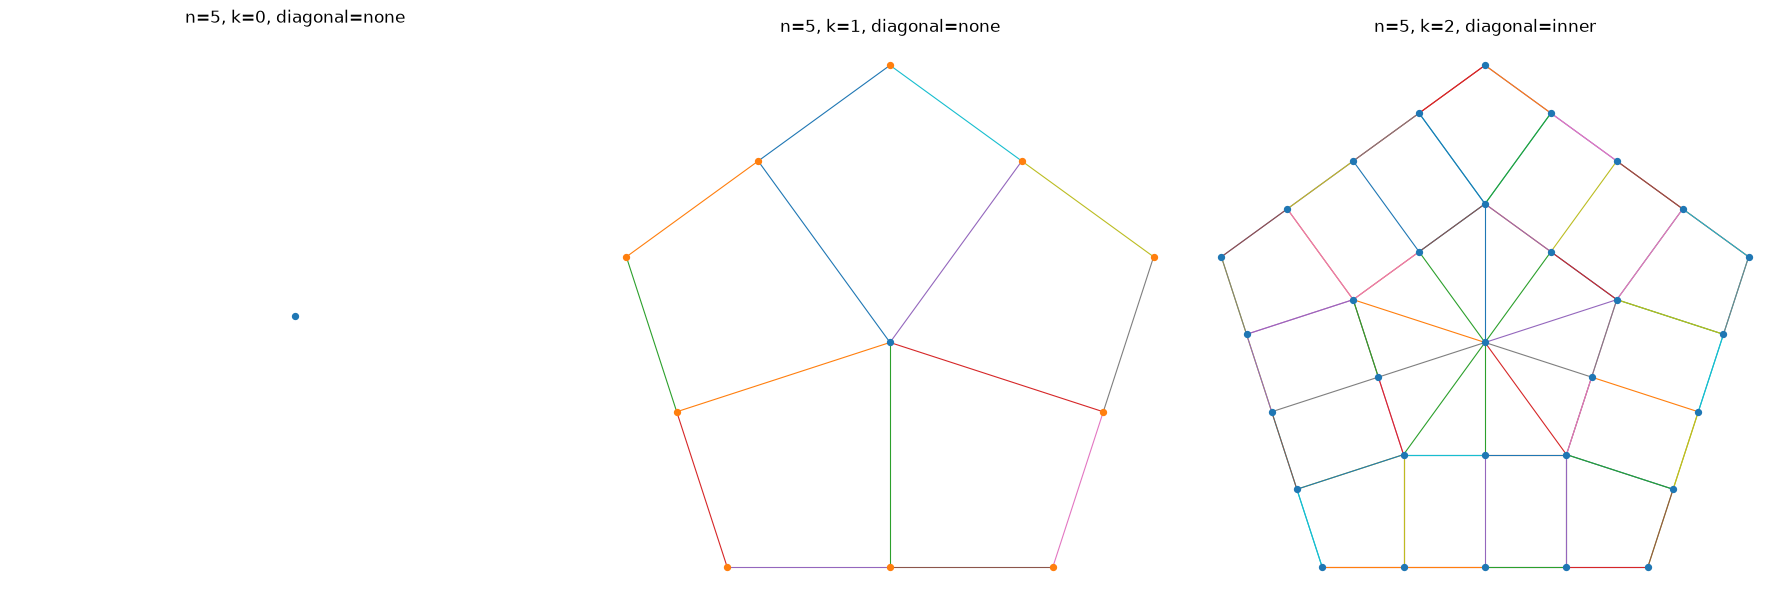

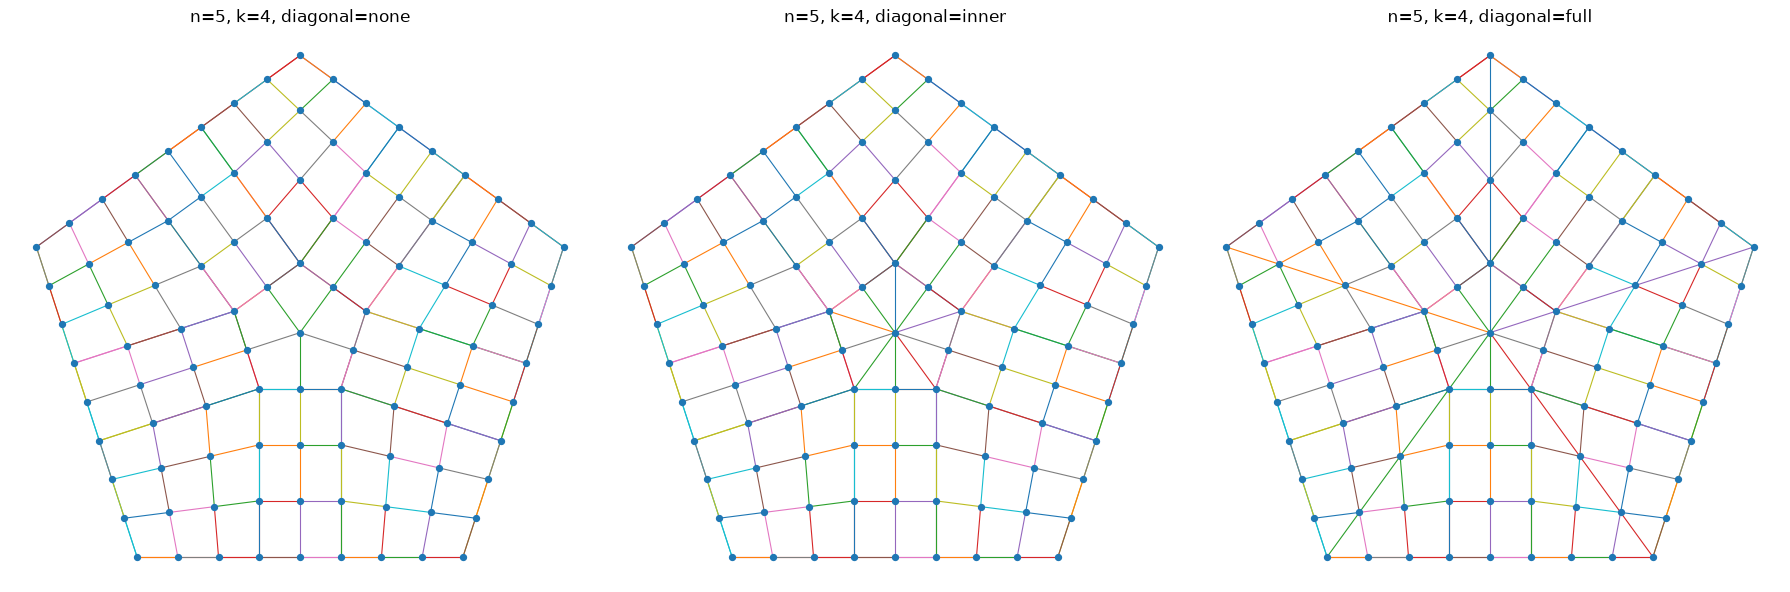

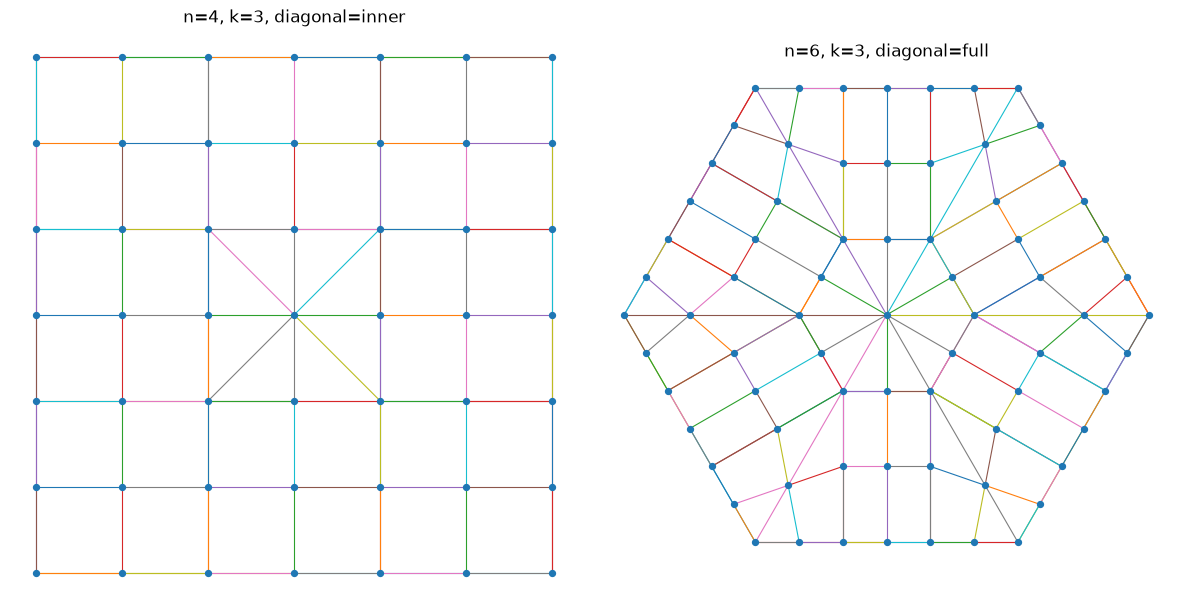

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 기본 기하 함수
# ============================================================

def regpoly(n, R, phase=None):
    """
    외접반지름 R인 정n각형.

    홀수 n:
        꼭짓점 하나가 위쪽을 향함.

    짝수 n:
        홀수 n 기준에서 pi/n 만큼 회전.
        즉 사용자가 의도한 배향으로 맞춤.
    """

    if phase is None:
        phase = np.pi / 2

        if n % 2 == 0:
            phase += np.pi / n

    theta = phase + 2 * np.pi * np.arange(n) / n

    return np.column_stack([
        R * np.cos(theta),
        R * np.sin(theta)
    ])

def lerp(a, b, t):
    """선분 a-b의 선형보간."""
    return (1 - t) * a + t * b


def bilerp(A, B, C, D, u, v):
    """
    사각형 A-B-C-D의 bilinear interpolation.

        A -------- B
        |          |
        |          |
        D -------- C
    """
    return (
        (1-u) * (1-v) * A
        + u * (1-v) * B
        + u * v * C
        + (1-u) * v * D
    )


# ============================================================
# 실제 격자 생성
# ============================================================

def build_grid(n=5, k=2, inner_radius=1.0):
    """
    n각형 order-k 격자를 생성한다.

    규칙
    ----
    k = 0
        중앙점 하나.

    k = 1
        바깥 정n각형의 꼭짓점 + 변 중앙점 = 총 2n개.
        작은 정n각형은 생성하지 않는다.

    k >= 2
        - 중앙 정n각형 외접반지름 = 1
        - 바깥 정n각형 외접반지름 = n
        - 바깥 둘레는 전체적으로 2n등분
          => 각 변의 꼭짓점/변중앙점
        - 변 중앙 방향에 방사형 직사각형 격자
        - 꼭짓점 방향에 k x k bilinear 격자
        - bilinear 기준점은
          '바깥 변 중앙 -> 꼭짓점' 반선분을 k등분했을 때
          변 중앙에서 한 칸 떨어진 점

    반환
    ----
    P : dict
        각 논리적 노드의 실제 (x,y) 좌표.

    E : list
        기본 격자선의 endpoint key 쌍.

    meta : dict
        draw()에서 필요한 기하 정보.
    """

    if n < 3:
        raise ValueError("n은 3 이상이어야 합니다.")

    if k < 0:
        raise ValueError("k는 0 이상이어야 합니다.")

    C = np.array([0.0, 0.0])


    # ========================================================
    # k = 0
    # ========================================================

    if k == 0:

        P = {
            ("C",): C
        }

        E = []

        meta = {
            "center": C,
            "inner_vertices": None,
            "outer_vertices": None
        }

        return P, E, meta


    # ========================================================
    # 바깥 정n각형
    # ========================================================

    OV = regpoly(
        n=n,
        R=k
    )

    OM = (
        OV
        + np.roll(OV, -1, axis=0)
    ) / 2


    # ========================================================
    # k = 1
    # ========================================================

    # ========================================================
    # k = 1
    # ========================================================

    if k == 1:

        P = {}
        E = []

        # 실제 값이 들어가는 점은 정확히 2n개
        for i in range(n):

            j = (i + 1) % n

            P[("OV", i)] = OV[i]
            P[("OM", i)] = OM[i]

            # 바깥 n각형의 변
            # 꼭짓점 -- 변중앙 -- 다음 꼭짓점
            E += [
                (
                    ("OV", i),
                    ("OM", i)
                ),
                (
                    ("OM", i),
                    ("OV", j)
                )
            ]

        meta = {
            "center": C,
            "inner_vertices": None,
            "outer_vertices": OV,

            # k=1에서만 사용할 방사선 정보
            "center_rays": OM
        }

        return P, E, meta


    # ========================================================
    # k >= 2
    # ========================================================

    IV = regpoly(
        n=n,
        R=inner_radius
    )

    IM = (
        IV
        + np.roll(IV, -1, axis=0)
    ) / 2


    P = {
        ("C",): C
    }

    E = []


    # --------------------------------------------------------
    # 중앙 정n각형 + 바깥 정n각형
    # --------------------------------------------------------

    for i in range(n):

        j = (i + 1) % n

        P[("IV", i)] = IV[i]
        P[("IM", i)] = IM[i]

        P[("OV", i)] = OV[i]
        P[("OM", i)] = OM[i]


        # 중앙 정n각형
        # 각 변을 중앙점에서 2등분
        E += [
            (
                ("IV", i),
                ("IM", i)
            ),
            (
                ("IM", i),
                ("IV", j)
            )
        ]


        # 중앙점 -> 작은 정n각형 변 중앙
        E.append(
            (
                ("C",),
                ("IM", i)
            )
        )


        # 바깥 정n각형
        # 전체 둘레 2n등분
        E += [
            (
                ("OV", i),
                ("OM", i)
            ),
            (
                ("OM", i),
                ("OV", j)
            )
        ]


    # --------------------------------------------------------
    # bilinear 영역의 외곽 기준점
    #
    # 각 바깥 반변
    #
    #     변 중앙 ---------- 꼭짓점
    #
    # 을 k등분하고,
    # 변 중앙에서 꼭짓점 방향으로 한 칸 간 점.
    # --------------------------------------------------------

    ref_left = {}
    ref_right = {}

    for i in range(n):

        prev = (i - 1) % n

        # 이전 변의 중앙 -> 현재 꼭짓점
        ref_left[i] = lerp(
            OM[prev],
            OV[i],
            1.0 / k
        )

        # 현재 변의 중앙 -> 현재 꼭짓점
        ref_right[i] = lerp(
            OM[i],
            OV[i],
            1.0 / k
        )

        P[("REFL", i)] = ref_left[i]
        P[("REFR", i)] = ref_right[i]


    # --------------------------------------------------------
    # 변 중앙 방향의 방사형 영역
    #
    # 한 sector:
    #
    #     L --- A --- R
    #     |     |     |
    #     L --- A --- R
    #     |     |     |
    #     ...
    #
    # 각 방사열에는 k개의 점.
    # --------------------------------------------------------

    t_values = np.linspace(
        0.0,
        1.0,
        k
    )


    for i in range(n):

        j = (i + 1) % n


        # 왼쪽 방사열의 바깥 끝
        left_outer = ref_right[i]

        # 오른쪽 방사열의 바깥 끝
        right_outer = ref_left[j]


        for q, t in enumerate(t_values):

            # 왼쪽
            P[("L", i, q)] = lerp(
                IV[i],
                left_outer,
                t
            )

            # 중앙 방사축
            P[("A", i, q)] = lerp(
                IM[i],
                OM[i],
                t
            )

            # 오른쪽
            P[("R", i, q)] = lerp(
                IV[j],
                right_outer,
                t
            )


        # 가로 방향
        for q in range(k):

            E += [
                (
                    ("L", i, q),
                    ("A", i, q)
                ),
                (
                    ("A", i, q),
                    ("R", i, q)
                )
            ]


        # 방사 방향
        for q in range(k - 1):

            E += [
                (
                    ("L", i, q),
                    ("L", i, q + 1)
                ),
                (
                    ("A", i, q),
                    ("A", i, q + 1)
                ),
                (
                    ("R", i, q),
                    ("R", i, q + 1)
                )
            ]


    # --------------------------------------------------------
    # 꼭짓점 방향 bilinear 영역
    #
    # 네 기준점:
    #
    #             OV[i]
    #             /   \
    #        REFL       REFR
    #             \   /
    #              IV[i]
    #
    # 이 연꼴에 k x k개의 점을 배치.
    # --------------------------------------------------------

    uv = np.linspace(
        0.0,
        1.0,
        k
    )


    for i in range(n):

        A = IV[i]

        B = ref_left[i]

        C_outer = OV[i]

        D = ref_right[i]


        # k x k 점
        for a, u in enumerate(uv):

            for b, v in enumerate(uv):

                P[("K", i, a, b)] = bilerp(
                    A,
                    B,
                    C_outer,
                    D,
                    u,
                    v
                )


        # 첫 번째 격자 방향
        for a in range(k):

            for b in range(k - 1):

                E.append(
                    (
                        ("K", i, a, b),
                        ("K", i, a, b + 1)
                    )
                )


        # 두 번째 격자 방향
        for a in range(k - 1):

            for b in range(k):

                E.append(
                    (
                        ("K", i, a, b),
                        ("K", i, a + 1, b)
                    )
                )


    meta = {
        "center": C,
        "inner_vertices": IV,
        "outer_vertices": OV
    }

    return P, E, meta


# ============================================================
# Plot
# ============================================================

def draw(
    n=5,
    k=2,
    diagonal_mode="none",
    show_nodes=True,
    ax=None
):
    """
    diagonal_mode

    "none"
        꼭짓점 방향 대각선 없음.

    "inner"
        중앙 -> 작은 정n각형 꼭짓점.
        즉 대각선 방향으로 1칸만.

    "full"
        중앙 -> 큰 정n각형 꼭짓점.
        전체 도형 끝까지 연장.

    홀수/짝수 n 모두 사용 가능.
    """

    if diagonal_mode not in (
        "none",
        "inner",
        "full"
    ):
        raise ValueError(
            "diagonal_mode은 "
            "'none', 'inner', 'full' 중 하나여야 합니다."
        )


    P, E, meta = build_grid(
        n=n,
        k=k
    )


    if ax is None:

        _, ax = plt.subplots(
            figsize=(8, 8)
        )


    # --------------------------------------------------------
    # 기본 격자선
    # --------------------------------------------------------

    for a, b in E:

        A = P[a]
        B = P[b]

        ax.plot(
            [A[0], B[0]],
            [A[1], B[1]],
            linewidth=0.8
        )
    # --------------------------------------------------------
    # k=1의 중심 -> 변 중앙 방사선
    #
    # 중심은 실제 노드가 아니므로 P에는 들어 있지 않지만
    # 선 자체는 그린다.
    # --------------------------------------------------------

    if k == 1:

        C = meta["center"]

        for M in meta["center_rays"]:

            ax.plot(
                [C[0], M[0]],
                [C[1], M[1]],
                linewidth=0.8
            )
        # 중앙점
        ax.scatter(
            [C[0]],
            [C[1]],
            s=18,
            zorder=5
        )
    # --------------------------------------------------------
    # 꼭짓점 방향 대각선
    # --------------------------------------------------------

    C = meta["center"]


    if diagonal_mode == "inner":

        # 작은 정n각형이 존재하는 k >= 2에서만.
        IV = meta["inner_vertices"]

        if IV is not None:

            for i in range(n):

                V = IV[i]

                ax.plot(
                    [C[0], V[0]],
                    [C[1], V[1]],
                    linewidth=0.8
                )


    elif diagonal_mode == "full":

        # k=0에는 바깥 정n각형 자체가 없음.
        OV = meta["outer_vertices"]

        if OV is not None:

            for i in range(n):

                V = OV[i]

                ax.plot(
                    [C[0], V[0]],
                    [C[1], V[1]],
                    linewidth=0.8
                )


    # --------------------------------------------------------
    # 실제 노드 표시
    # --------------------------------------------------------

    if show_nodes:

        xy = np.array(
            list(P.values())
        )

        # 여러 논리 인덱스가 동일한 실제 점을 가리킬 수 있으므로
        # plot에서는 중복 제거.
        xy = np.unique(
            np.round(xy, 10),
            axis=0
        )

        ax.scatter(
            xy[:, 0],
            xy[:, 1],
            s=18,
            zorder=5
        )


    ax.set_aspect(
        "equal"
    )

    ax.axis(
        "off"
    )

    ax.set_title(
        f"n={n}, k={k}, "
        f"diagonal={diagonal_mode}"
    )


    return ax


# ============================================================
# 사용 예
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # k = 0, 1, 2 비교
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 6)
    )

    draw(
        n=5,
        k=0,
        diagonal_mode="none",
        ax=axes[0]
    )

    draw(
        n=5,
        k=1,
        diagonal_mode="none",
        ax=axes[1]
    )

    draw(
        n=5,
        k=2,
        diagonal_mode="inner",
        ax=axes[2]
    )

    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # k = 4:
    # 대각선 없음 / 한 칸 / 전체
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 6)
    )

    draw(
        n=5,
        k=4,
        diagonal_mode="none",
        ax=axes[0]
    )

    draw(
        n=5,
        k=4,
        diagonal_mode="inner",
        ax=axes[1]
    )

    draw(
        n=5,
        k=4,
        diagonal_mode="full",
        ax=axes[2]
    )

    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # 짝수 n 확인
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 6)
    )

    draw(
        n=4,
        k=3,
        diagonal_mode="inner",
        ax=axes[0]
    )

    draw(
        n=6,
        k=3,
        diagonal_mode="full",
        ax=axes[1]
    )

    plt.tight_layout()
    plt.show()

In [6]:
# ============================================================
# 논리 레이블 / 숫자 계층
# ============================================================

def _coord_key(xy, decimals=10):
    """
    부동소수점 좌표를 동일점 판별용 tuple로 변환.
    """
    xy = np.asarray(xy, dtype=float)
    return tuple(np.round(xy, decimals))


def get_unique_points(P, decimals=10):
    """
    build_grid()의 P에 중복 저장된 동일 좌표를 하나의
    geometry point로 합친다.

    주의:
        여기서 얻는 point_id는 '기하학적 point id'이다.
        실제 마법진 숫자칸의 순번과는 별개이다.
    """

    coord_to_id = {}
    key_to_id = {}
    points = []

    for key, xy in P.items():

        ck = _coord_key(
            xy,
            decimals=decimals
        )

        if ck not in coord_to_id:

            point_id = len(points)

            coord_to_id[ck] = point_id

            points.append(
                np.asarray(
                    xy,
                    dtype=float
                )
            )

        key_to_id[key] = coord_to_id[ck]

    return (
        np.asarray(points),
        key_to_id,
        coord_to_id
    )


# ============================================================
# 논리 sector 행렬 생성
# ============================================================

def build_label_grid(
    n=5,
    k=2,
    inner_radius=1.0,
    decimals=10
):
    """
    기존 build_grid() 위에 마법진의 논리적 숫자칸을 만든다.

    ----------------------------------------------------------
    k >= 2의 sector i
    ----------------------------------------------------------

    각 sector는

        k x (k+1)

    행렬이다.

    첫 세로줄:
        A[i, r]

    나머지 k x k:
        K[i, r, c]

    즉

        [ A | K ]

    로 직접 대응한다.

    최근접점 탐색은 하지 않는다.


    ----------------------------------------------------------
    중앙
    ----------------------------------------------------------

    중앙점은 sector 행렬과 별개의 숫자칸이다.

    따라서 전체 숫자칸 수는

        n * k * (k+1) + 1

    로 취급한다.


    ----------------------------------------------------------
    k = 1
    ----------------------------------------------------------

    sector마다

        [ OM | OV ]

    의 1 x 2 행렬을 사용한다.

    중앙점 역시 별도의 숫자칸이다.


    ----------------------------------------------------------
    k = 0
    ----------------------------------------------------------

    중앙점 하나만 존재한다.
    """

    P, E, meta = build_grid(
        n=n,
        k=k,
        inner_radius=inner_radius
    )

    (
        geometry_points,
        key_to_geometry_id,
        coord_to_geometry_id
    ) = get_unique_points(
        P,
        decimals=decimals
    )


    # ========================================================
    # k = 0
    # ========================================================

    if k == 0:

        center_xy = np.asarray(
            meta["center"],
            dtype=float
        )

        # 실제 숫자칸은 중앙 하나
        cell_points = np.array([
            center_xy
        ])

        return {
            "n": n,
            "k": k,

            # 원래 geometry
            "P": P,
            "E": E,
            "meta": meta,

            # geometry 정보
            "geometry_points": geometry_points,
            "key_to_geometry_id": key_to_geometry_id,

            # sector는 비어 있음
            "labels": np.empty(
                (n, 0, 1),
                dtype=int
            ),

            # magic-cell ID
            "center_id": 0,

            # 실제 숫자칸 좌표
            "cell_points": cell_points,

            # 숫자
            "values": np.full(
                1,
                None,
                dtype=object
            )
        }


    # ========================================================
    # k = 1
    #
    # sector i:
    #
    #     [ OM[i] | OV[i] ]
    #
    # + 중앙점
    # ========================================================

    if k == 1:

        labels = np.empty(
            (n, 1, 2),
            dtype=int
        )

        cell_points = []
        coord_to_cell_id = {}


        def register_cell(xy):

            ck = _coord_key(
                xy,
                decimals=decimals
            )

            if ck not in coord_to_cell_id:

                cell_id = len(cell_points)

                coord_to_cell_id[ck] = cell_id

                cell_points.append(
                    np.asarray(
                        xy,
                        dtype=float
                    )
                )

            return coord_to_cell_id[ck]


        # sector 숫자칸
        for i in range(n):

            labels[i, 0, 0] = register_cell(
                P[("OM", i)]
            )

            labels[i, 0, 1] = register_cell(
                P[("OV", i)]
            )


        # 중앙도 반드시 숫자칸
        center_id = register_cell(
            meta["center"]
        )


        cell_points = np.asarray(
            cell_points
        )


        return {
            "n": n,
            "k": k,

            "P": P,
            "E": E,
            "meta": meta,

            "geometry_points": geometry_points,
            "key_to_geometry_id": key_to_geometry_id,

            "labels": labels,

            "center_id": center_id,

            "cell_points": cell_points,

            "values": np.full(
                len(cell_points),
                None,
                dtype=object
            )
        }


    # ========================================================
    # k >= 2
    #
    # sector:
    #
    #        col 0       col 1 ... col k
    #
    #          A       |       K
    #
    # row 0   A0       | K00 K01 ...
    # row 1   A1       | K10 K11 ...
    # ...
    # ========================================================

    labels = np.empty(
        (n, k, k + 1),
        dtype=int
    )

    cell_points = []
    coord_to_cell_id = {}


    def register_cell(xy):
        """
        실제 숫자가 들어가는 점만 등록한다.

        같은 실제 좌표가 여러 key로 표현되어도
        하나의 magic-cell ID를 갖는다.
        """

        ck = _coord_key(
            xy,
            decimals=decimals
        )

        if ck not in coord_to_cell_id:

            cell_id = len(cell_points)

            coord_to_cell_id[ck] = cell_id

            cell_points.append(
                np.asarray(
                    xy,
                    dtype=float
                )
            )

        return coord_to_cell_id[ck]



    # --------------------------------------------------------
    # sector 행렬을 행 우선(row-major)으로 등록
    #
    # [ A0 | K00 K01 ... ]
    # [ A1 | K10 K11 ... ]
    # [ A2 | K20 K21 ... ]
    # ...
    # --------------------------------------------------------

    for i in range(n):

        for r in range(k):

            for c in range(k + 1):

                if c == 0:
                    # 첫 열 = A
                    xy = P[
                        ("A", i, r)
                    ]

                else:
                    # 나머지 k열 = K
                    xy = P[
                        ("K", i, c - 1, r)
                    ]

                labels[
                    i,
                    r,
                    c
                ] = register_cell(xy)


    # --------------------------------------------------------
    # 중앙점도 별도의 숫자칸
    # --------------------------------------------------------

    center_id = register_cell(
        meta["center"]
    )


    cell_points = np.asarray(
        cell_points
    )


    return {
        "n": n,
        "k": k,

        "P": P,
        "E": E,
        "meta": meta,

        # 전체 geometry
        "geometry_points": geometry_points,
        "key_to_geometry_id": key_to_geometry_id,

        # 마법진 논리구조
        "labels": labels,
        "center_id": center_id,

        # 실제 숫자가 들어가는 점만
        "cell_points": cell_points,

        "values": np.full(
            len(cell_points),
            None,
            dtype=object
        )
    }


# ============================================================
# 구조 검사
# ============================================================

def print_label_grid(G):
    """
    sector별 magic-cell ID 행렬 출력.
    """

    n = G["n"]
    k = G["k"]

    labels = G["labels"]

    print(
        f"n = {n}, k = {k}"
    )

    print(
        "number of magic cells =",
        len(G["cell_points"])
    )

    print(
        "center_id =",
        G["center_id"]
    )

    print()

    for i in range(n):

        print(
            f"sector {i}"
        )

        print(
            labels[i]
        )

        print()


# ============================================================
# 기대 숫자칸 수 검사
# ============================================================

def check_cell_count(G):
    """
    현재 정의에서

        k = 0:
            1

        k >= 1:
            n*k*(k+1) + 1

    인지 검사한다.
    """

    n = G["n"]
    k = G["k"]

    if k == 0:
        expected = 1

    else:
        expected = (
            n * k * (k + 1)
            + 1
        )

    actual = len(
        G["cell_points"]
    )

    print(
        f"expected = {expected}"
    )

    print(
        f"actual   = {actual}"
    )

    if expected == actual:

        print("OK")

    else:

        print(
            "WARNING: "
            "sector 사이에 동일 좌표가 공유되거나 "
            "레이블 대응을 다시 확인해야 합니다."
        )

    return expected == actual


# ============================================================
# 숫자 입력
# ============================================================

def set_values(
    G,
    values
):
    """
    magic-cell ID 순서대로 숫자를 입력한다.

    geometry의 보조점에는 숫자를 넣지 않는다.
    """

    values = list(values)

    N = len(
        G["cell_points"]
    )

    if len(values) != N:

        raise ValueError(
            f"숫자가 {N}개 필요하지만 "
            f"{len(values)}개가 입력되었습니다."
        )

    G["values"] = np.asarray(
        values,
        dtype=object
    )

    return G


# ============================================================
# sector 행렬에 직접 숫자 입력
# ============================================================

def set_sector_values(
    G,
    sector_values,
    center_value=None
):
    """
    sector_values의 shape:

        (n, k, k+1)

    각 sector 행렬의 값을 실제 magic-cell에 기록한다.

    중앙값은 center_value로 별도 지정한다.
    """

    n = G["n"]
    k = G["k"]

    sector_values = np.asarray(
        sector_values,
        dtype=object
    )

    expected_shape = (
        n,
        k,
        k + 1
    )

    if sector_values.shape != expected_shape:

        raise ValueError(
            f"sector_values shape은 "
            f"{expected_shape}이어야 하지만 "
            f"{sector_values.shape}입니다."
        )


    for i in range(n):

        for r in range(k):

            for c in range(k + 1):

                cell_id = G[
                    "labels"
                ][i, r, c]

                G[
                    "values"
                ][cell_id] = (
                    sector_values[
                        i, r, c
                    ]
                )


    if center_value is not None:

        G[
            "values"
        ][
            G["center_id"]
        ] = center_value


    return G


# ============================================================
# sector matrix 형태로 값 읽기
# ============================================================

def get_sector_values(
    G,
    sector
):
    """
    특정 sector의 k x (k+1) 숫자 행렬.
    """

    ids = G[
        "labels"
    ][sector]

    return G[
        "values"
    ][ids]


def get_center_value(G):
    """
    중앙 숫자 반환.
    """

    return G[
        "values"
    ][
        G["center_id"]
    ]


# ============================================================
# 숫자 / label plot
# ============================================================

def draw_labeled_grid(
    G,
    diagonal_mode="none",
    show_cell_ids=False,
    show_numbers=True,
    show_nodes=True,
    ax=None
):
    """
    기존 build_grid()의 geometry 위에
    실제 마법진 숫자칸만 표시한다.

    geometry용 보조점은 숫자칸으로 표시하지 않는다.
    """

    n = G["n"]
    k = G["k"]

    P = G["P"]
    E = G["E"]
    meta = G["meta"]

    cell_points = G[
        "cell_points"
    ]

    values = G[
        "values"
    ]


    if ax is None:

        _, ax = plt.subplots(
            figsize=(8, 8)
        )


    # ========================================================
    # 기본 격자선
    # ========================================================

    for a, b in E:

        A = P[a]
        B = P[b]

        ax.plot(
            [A[0], B[0]],
            [A[1], B[1]],
            linewidth=0.8
        )


    # ========================================================
    # k=1 중심 -> 변 중앙
    # ========================================================

    if k == 1:

        C = meta[
            "center"
        ]

        for M in meta[
            "center_rays"
        ]:

            ax.plot(
                [C[0], M[0]],
                [C[1], M[1]],
                linewidth=0.8
            )


    # ========================================================
    # 대각선
    # ========================================================

    C = meta[
        "center"
    ]


    if diagonal_mode == "inner":

        IV = meta[
            "inner_vertices"
        ]

        if IV is not None:

            for V in IV:

                ax.plot(
                    [C[0], V[0]],
                    [C[1], V[1]],
                    linewidth=0.8
                )


    elif diagonal_mode == "full":

        OV = meta[
            "outer_vertices"
        ]

        if OV is not None:

            for V in OV:

                ax.plot(
                    [C[0], V[0]],
                    [C[1], V[1]],
                    linewidth=0.8
                )


    elif diagonal_mode != "none":

        raise ValueError(
            "diagonal_mode은 "
            "'none', 'inner', 'full' 중 하나여야 합니다."
        )


    # ========================================================
    # 실제 숫자칸 노드
    # ========================================================

    if show_nodes:

        ax.scatter(
            cell_points[:, 0],
            cell_points[:, 1],
            s=18,
            zorder=5
        )


    # ========================================================
    # 숫자
    # ========================================================

    if show_numbers:

        for cell_id, xy in enumerate(
            cell_points
        ):

            value = values[
                cell_id
            ]

            if value is not None:

                ax.text(
                    xy[0],
                    xy[1],
                    str(value),
                    ha="center",
                    va="center",
                    fontsize=9,
                    zorder=10
                )


    # ========================================================
    # magic-cell ID
    # ========================================================

    if show_cell_ids:

        for cell_id, xy in enumerate(
            cell_points
        ):

            ax.text(
                xy[0],
                xy[1],
                str(cell_id),
                ha="left",
                va="bottom",
                fontsize=7,
                zorder=11
            )


    ax.set_aspect(
        "equal"
    )

    ax.axis(
        "off"
    )

    ax.set_title(
        f"n={n}, k={k}"
    )

    return ax

In [7]:
G = build_label_grid(
    n=5,
    k=2
)

print_label_grid(G)
check_cell_count(G)

n = 5, k = 2
number of magic cells = 31
center_id = 30

sector 0
[[0 1 2]
 [3 4 5]]

sector 1
[[ 6  7  8]
 [ 9 10 11]]

sector 2
[[12 13 14]
 [15 16 17]]

sector 3
[[18 19 20]
 [21 22 23]]

sector 4
[[24 25 26]
 [27 28 29]]

expected = 31
actual   = 31
OK


True

## Lattice Magic Polygon / 격자다각진 
 
The term **Lattice Magic Polygon** is used in this project for a magic 
figure in which numbers are arranged on a polygonal lattice and the 
magic conditions are imposed on lines of the lattice rather than only 
on the boundary or individual polygonal layers. 
 
본 프로젝트에서는 다각형 내부에 격자 형태로 수를 배열하고, 다각형의 
둘레나 개별 층에 한정하지 않고 **격자를 이루는 줄 단위로 마법합 조건을 
적용하는 형태의 수 배열**을 **격자다각진**이라고 부릅니다. 
 
The 19-node Magic Triangle included in this project is an existing example 
of this type of construction, although its original author did not assign 
a specific name to this class of magic polygons. 
 
본 프로젝트에 수록된 **19-node Magic Triangle**은 이러한 유형의 기존 
사례이지만, 원저자는 이 유형의 다각진 자체에 별도의 명칭을 
부여하지 않았습니다.

In [9]:
# ============================================================
# 기존 31-node 오각진 해를 새 geometry로 출력
# ============================================================

def draw_magic_figure(
    sector_values,
    center_value,
    n=5,
    k=2,
    magic_sum=None,
    title=None,
    inner_radius=1.0,
    diagonal_mode="full",
    show_nodes=True,
    figsize=(8, 8)
):
    """
    sector_values:
        shape = (n, k, k+1)

        n=5, k=2이면 정확히 (5,2,3),
        즉 30개 숫자.

    center_value:
        중앙 숫자 1개.

    따라서 31-node pentagonal magic figure는

        5 x 2 x 3 + center

    로 입력한다.
    """

    sector_values = np.asarray(
        sector_values,
        dtype=object
    )

    expected_shape = (
        n,
        k,
        k + 1
    )

    if sector_values.shape != expected_shape:
        raise ValueError(
            f"sector_values shape은 "
            f"{expected_shape}이어야 합니다. "
            f"현재: {sector_values.shape}"
        )

    # --------------------------------------------------------
    # geometry + logical labels
    # --------------------------------------------------------

    G = build_label_grid(
        n=n,
        k=k,
        inner_radius=inner_radius
    )

    # --------------------------------------------------------
    # 숫자 배치
    # --------------------------------------------------------

    set_sector_values(
        G,
        sector_values,
        center_value=center_value
    )

    # --------------------------------------------------------
    # plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=figsize
    )

    draw_labeled_grid(
        G,
        diagonal_mode=diagonal_mode,
        show_cell_ids=False,
        show_numbers=False,
        show_nodes=False,
        ax=ax
    )

    # --------------------------------------------------------
    # 숫자를 원형 node로 출력
    # --------------------------------------------------------

    for cell_id, xy in enumerate(
        G["cell_points"]
    ):

        value = G["values"][cell_id]

        ax.text(
            xy[0],
            xy[1],
            str(value),
            ha="center",
            va="center",
            fontsize=11,
            zorder=20,

            bbox=dict(
                boxstyle="circle,pad=0.25",
                facecolor="white",
                edgecolor="black",
                linewidth=1.2
            )
        )

    # --------------------------------------------------------
    # 제목
    # --------------------------------------------------------

    N = len(
        G["cell_points"]
    )
    if title is None:

        if magic_sum is None:
            title = f"{N}-node Magic Figure"

        else:
            title = (
                f"{N}-node Magic Figure "
                f"— Magic Sum {magic_sum}"
            )

    ax.set_title(
        title,
        fontsize=16,
        pad=18
    )

    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()

    return G, fig, ax

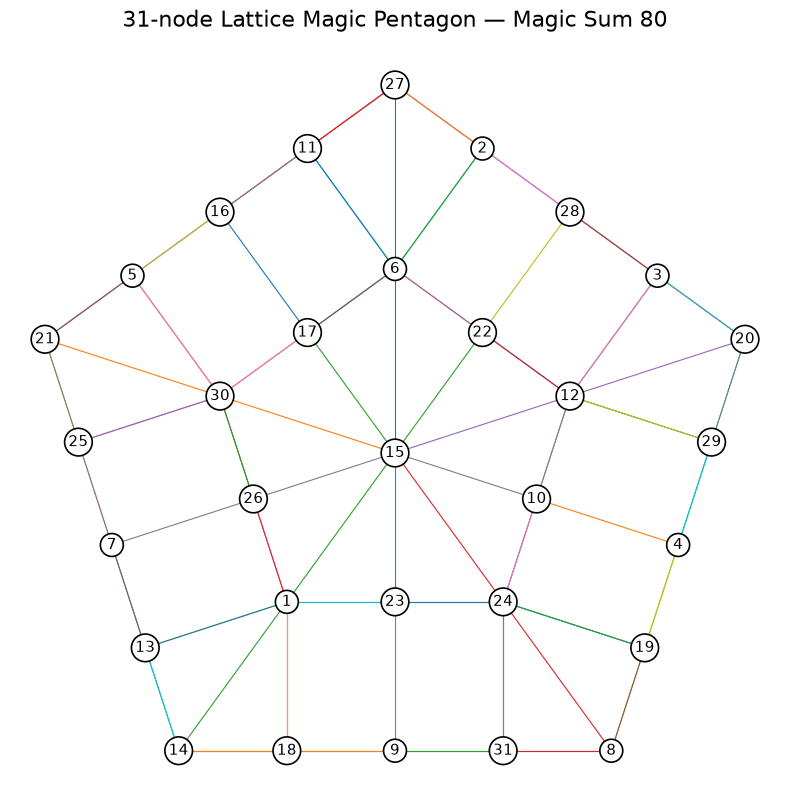

In [10]:
# ============================================================
# 31-node Magic Figure
# Magic Sum = 80
#
# ============================================================

sector_values = np.array([
    # --------------------------------------------------------
    # sector 0 : 
    # --------------------------------------------------------
    [
        [17, 6, 2],
        [16,  11, 27],
    ],

    # --------------------------------------------------------
    # sector 1 : 
    # --------------------------------------------------------
    [
        [26, 30, 5],
        [7, 25, 21],
    ],

    # --------------------------------------------------------
    # sector 2 : 
    # --------------------------------------------------------
    [
        [23,  1, 13],
        [9, 18, 14],
    ],
    # --------------------------------------------------------
    # sector 3 : 
    # --------------------------------------------------------

    [
        [10, 24, 31],
        [4, 19,  8],
    ],
    # --------------------------------------------------------
    # sector 4 : 
    # --------------------------------------------------------
    [
        [22, 12,  29],
        [28, 3, 20],
    ], 
])

center_value = 15


G, fig, ax = draw_magic_figure(
    sector_values=sector_values,
    center_value=center_value,

    n=5,
    k=2,

    magic_sum=80,
    title="31-node Lattice Magic Pentagon — Magic Sum 80",
    inner_radius=1.0,

    diagonal_mode="full",

    figsize=(8, 8)
)

plt.show()

<Axes: title={'center': 'n=3, k=2, diagonal=full'}>

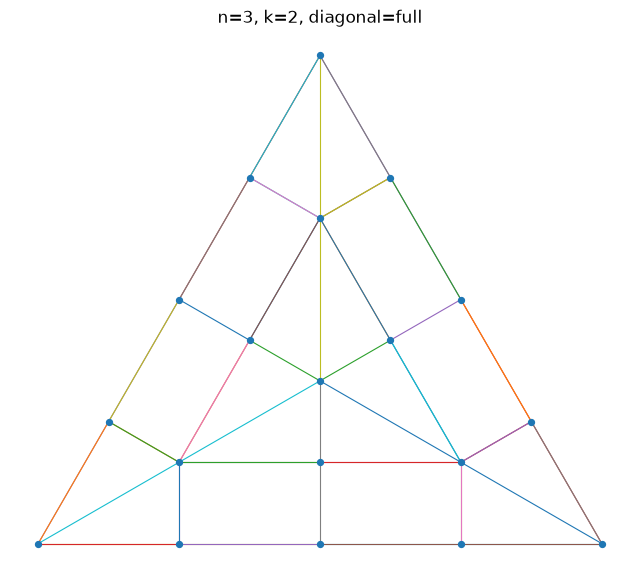

In [11]:
    draw(
        n=3,
        k=2,
        diagonal_mode="full"
    )

magic triangle: 0~18


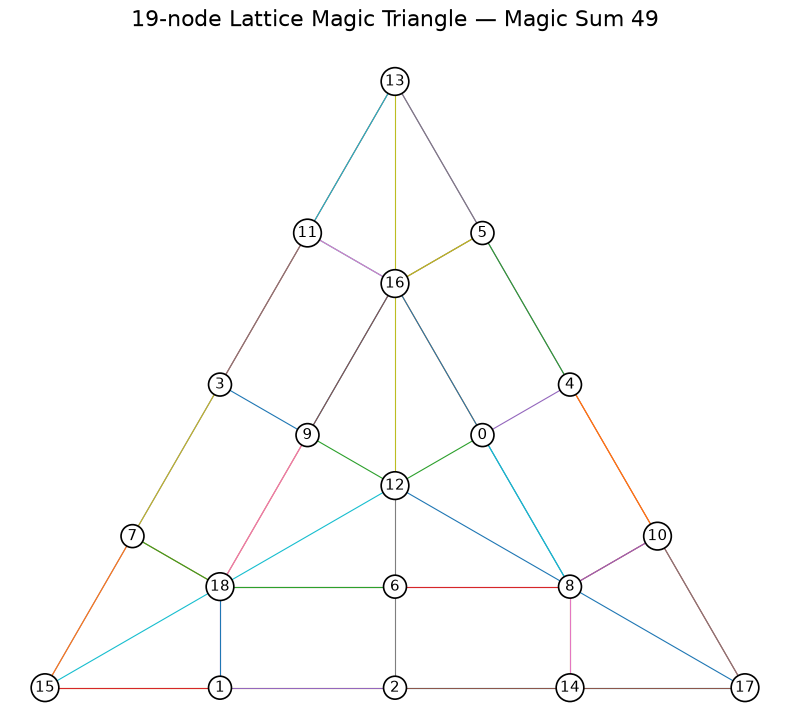

In [12]:
# https://commons.wikimedia.org/wiki/File:Rightside_Slidey_O-2_S-3_Cps-5_R-3_AddsTo_49_Using_0_To_18.0000000511_2.jpg
# ============================================================
# 19-node Magic Triangle
# Magic Sum = 49
# 0부터 18까지 사용
# ============================================================

sector_values = np.array([
    # --------------------------------------------------------
    # sector 0 : 
    # --------------------------------------------------------
    [
        [9, 16, 5],
        [3,  11, 13],
    ],

    # --------------------------------------------------------
    # sector 1 : 
    # --------------------------------------------------------
    [
        [6, 18, 7],
        [2, 1,  15],
    ],

    # --------------------------------------------------------
    # sector 2 : 
    # --------------------------------------------------------
    [
        [0, 8,  14],
        [4, 10, 17],
    ],


])

center_value = 12

print("magic triangle: 0~18")
G, fig, ax = draw_magic_figure(
    sector_values=sector_values,
    center_value=center_value,

    n=3,
    k=2,

    magic_sum=49,

    inner_radius=1.0,
    title="19-node Lattice Magic Triangle — Magic Sum 49",
    diagonal_mode="full",

    figsize=(8, 8)
)

plt.show()

## Other Examples / 다른 예

The **Polygonal Array System** can also represent other forms of magic polygons, including constructions consisting of **nested polygons whose perimeter sides have equal sums**. An example of a seven-layer Magic Pentagon using the integers 1 through 211 can be found here:

- [Magic Pentagon (Reddit, r/math)](https://www.reddit.com/r/math/comments/8cq2yx/magic_pentagon/)

**Polygonal Array System**은 각 껍질의 변의 합이 같도록 구성된 **동심 다각형 형태의 Magic Polygon**도 표현할 수 있습니다. 1부터 211까지의 정수를 사용한 7껍질 동심 Magic Pentagon의 사례는 다음 링크에서 확인할 수 있습니다:

- [Magic Pentagon (Reddit, r/math)](https://www.reddit.com/r/math/comments/8cq2yx/magic_pentagon/)

<Axes: title={'center': 'n=5, k=6, diagonal=none'}>

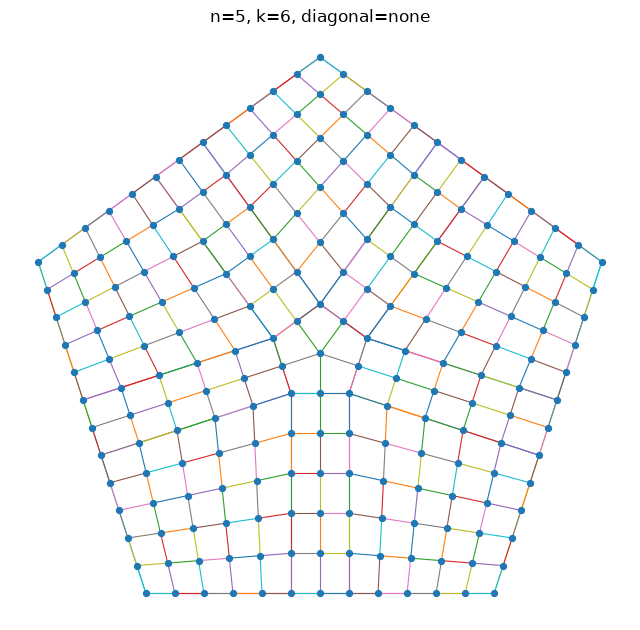

In [14]:
    draw(
        n=5,
        k=6,
        diagonal_mode="none"
    )

## Possible Extensions / 가능한 확장

By adding **rectangular regions** to the **Polygonal Array System**, the
system could also be used to construct game boards combining rectangular
and polygonal structures. Possible applications include boards for
**multi-player Janggi, multi-player chess, and other board games**.

Since chess and many other board games represent positions by **cells rather
than vertices**, an extension for **cell coloring and rendering** may also
be required to support such applications.

**Polygonal Array System**에 **직사각형 영역**을 추가하면 직사각형과
다각형 구조가 결합된 게임판을 구성하는 데에도 활용할 수 있습니다.
가능한 활용 사례로는 **다인용 장기판, 다인용 체스판 및 기타 보드게임의
게임판**이 있습니다.

체스를 비롯한 여러 보드게임은 꼭짓점이 아닌 **칸(cell) 단위**로 위치를
표현하므로, 이러한 용도를 지원하기 위해서는 **칸의 채색 및 렌더링을
위한 코드**를 추가할 필요가 있을 수 있습니다.